=== Otimização Multidimensional Sem Restrições ===



--- Iniciando Aclive Máximo ---
Iter: 00 | (x, y): (-2.0000, 3.0000) | f(x,y): -38.0000 | h: 0.1923 | Erro: 20.0000
Iter: 01 | (x, y): (0.3077, -0.0769) | f(x,y): 0.4615 | h: 1.2500 | Erro: 1.5385
Iter: 02 | (x, y): (1.8462, 1.0769) | f(x,y): 1.9408 | h: 0.1923 | Erro: 0.7692
Iter: 03 | (x, y): (1.9349, 0.9586) | f(x,y): 1.9977 | h: 1.2500 | Erro: 0.0592
Iter: 04 | (x, y): (1.9941, 1.0030) | f(x,y): 1.9999 | h: 0.1923 | Erro: 0.0296
Iter: 05 | (x, y): (1.9975, 0.9984) | f(x,y): 2.0000 | h: 0.2000 | Erro: 0.0023
Iter: 06 | (x, y): (1.9979, 0.9987) | f(x,y): 2.0000 | h: 0.2000 | Erro: 0.0019
Iter: 07 | (x, y): (1.9982, 0.9989) | f(x,y): 2.0000 | h: 0.2000 | Erro: 0.0016
Iter: 08 | (x, y): (1.9985, 0.9991) | f(x,y): 2.0000 | h: 0.2000 | Erro: 0.0014
Iter: 09 | (x, y): (1.9987, 0.9992) | f(x,y): 2.0000 | h: 0.2000 | Erro: 0.0012
Iter: 10 | (x, y): (1.9989, 0.9993) | f(x,y): 2.0000 | h: 0.2000 | Erro: 0.0010
Iter: 11 | (x, y): (1.9991, 0.9994) | f(x,y): 2.0000 | h: 0.2000 | Erro: 0.0008
It

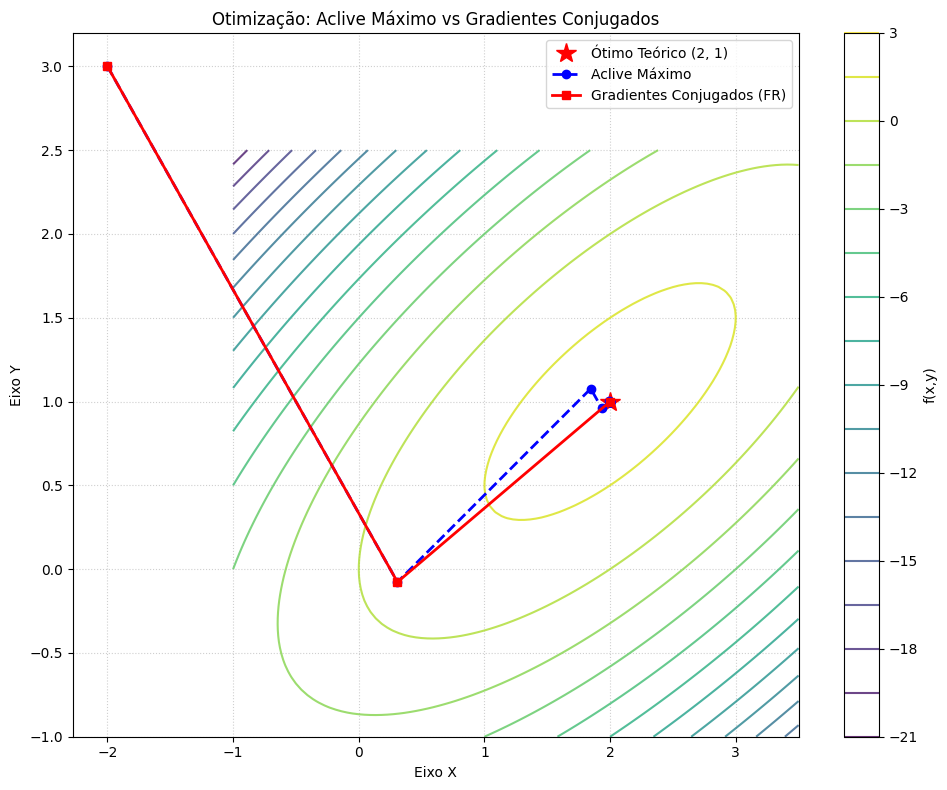

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Definição da Função e do Gradiente
# ==========================================

def f(x, y):
    """Função objetivo a ser maximizada."""
    return 2*x*y + 2*x - x**2 - 2*y**2

def grad_f(x, y):
    """Vetor gradiente da função objetivo."""
    df_dx = 2*y + 2 - 2*x
    df_dy = 2*x - 4*y
    return np.array([df_dx, df_dy])

# ==========================================
# 2. Busca em Linha (Interpolação Quadrática)
# ==========================================

def line_search_quad(x, y, px, py, h0=0.0, h1=0.1, h2=0.2):
    """
    Realiza a busca unidimensional por interpolação quadrática para encontrar o passo h*.
    """
    # Avaliando a função nos três pontos de teste ao longo da direção de busca p
    g0 = f(x + h0*px, y + h0*py)
    g1 = f(x + h1*px, y + h1*py)
    g2 = f(x + h2*px, y + h2*py)
    
    # Numerador e Denominador da fórmula do vértice da parábola
    num = (h0**2 - h2**2)*g1 + (h2**2 - h1**2)*g0 + (h1**2 - h0**2)*g2
    den = (h0 - h2)*g1 + (h2 - h1)*g0 + (h1 - h0)*g2
    
    # Prevenção de divisão por zero (fallback)
    if abs(den) < 1e-8:
        # Se o denominador for muito pequeno (parábola degenerada), 
        # escolhe o h que deu o maior valor de g(h) empiricamente.
        h_vals = [h0, h1, h2]
        g_vals = [g0, g1, g2]
        return h_vals[np.argmax(g_vals)]
    
    h_star = num / (2 * den)
    return h_star

# ==========================================
# 3. Métodos de Otimização
# ==========================================

def steepest_ascent(x0, y0, tol=1e-5, max_iter=100):
    """Método do Aclive Máximo."""
    x, y = x0, y0
    history = []
    
    print("\n--- Iniciando Aclive Máximo ---")
    for i in range(max_iter):
        grad = grad_f(x, y)
        erro = np.linalg.norm(grad)
        
        # O Aclive Máximo usa o próprio gradiente como direção
        px, py = grad[0], grad[1]
        
        # Encontra o passo ótimo
        h = line_search_quad(x, y, px, py)
        
        # Registro histórico (iter erro h x y dfx dfy)
        history.append([i, erro, h, x, y, px, py])
        
        print(f"Iter: {i:02d} | (x, y): ({x:.4f}, {y:.4f}) | f(x,y): {f(x,y):.4f} | h: {h:.4f} | Erro: {erro:.4f}")
        
        if erro < tol:
            print("Convergência atingida!")
            break
            
        # Atualização da posição
        x = x + h * px
        y = y + h * py
        
    return np.array(history)

def conjugate_gradients_fr(x0, y0, tol=1e-5, max_iter=100):
    """Método dos Gradientes Conjugados (Fletcher-Reeves)."""
    x, y = x0, y0
    history = []
    
    # Inicialização da direção com o gradiente no ponto inicial
    grad = grad_f(x, y)
    px, py = grad[0], grad[1]
    
    print("\n--- Iniciando Gradientes Conjugados (Fletcher-Reeves) ---")
    for i in range(max_iter):
        erro = np.linalg.norm(grad)
        
        # Encontra o passo ótimo na direção atual
        h = line_search_quad(x, y, px, py)
        
        # Registro histórico
        history.append([i, erro, h, x, y, grad[0], grad[1]])
        
        print(f"Iter: {i:02d} | (x, y): ({x:.4f}, {y:.4f}) | f(x,y): {f(x,y):.4f} | h: {h:.4f} | Erro: {erro:.4f}")
        
        if erro < tol:
            print("Convergência atingida!")
            break
            
        # Atualização da posição
        x = x + h * px
        y = y + h * py
        
        # Calcula o novo gradiente
        grad_new = grad_f(x, y)
        
        # Calcula beta usando a fórmula de Fletcher-Reeves
        beta = np.dot(grad_new, grad_new) / np.dot(grad, grad)
        
        # Atualiza a direção de busca
        px = grad_new[0] + beta * px
        py = grad_new[1] + beta * py
        
        # Atualiza o gradiente atual para a próxima iteração
        grad = grad_new
        
    return np.array(history)

# ==========================================
# 4. Geração de Arquivos e Gráficos
# ==========================================

def save_output(filename, data):
    """Salva a matriz de histórico no formato exigido."""
    header = "iter erro h x y dfx dfy"
    np.savetxt(filename, data, fmt="%.6f", header=header, comments="")
    print(f"Arquivo '{filename}' salvo com sucesso.")

def generate_function_data_and_plot(hist_sa, hist_cg):
    """Gera o function.dat e plota as curvas de nível com as trajetórias."""
    # Malha para os dados e curvas de nível
    X_vals = np.linspace(-1, 3.5, 100)
    Y_vals = np.linspace(-1, 2.5, 100)
    X, Y = np.meshgrid(X_vals, Y_vals)
    Z = f(X, Y)
    
    # Salvar function.dat
    flat_X = X.flatten()
    flat_Y = Y.flatten()
    flat_Z = Z.flatten()
    func_data = np.column_stack((flat_X, flat_Y, flat_Z))
    np.savetxt("function.dat", func_data, fmt="%.4f", header="x y f", comments="")
    print("Arquivo 'function.dat' salvo com sucesso.\n")
    
    # Configuração do gráfico
    plt.figure(figsize=(10, 8))
    cp = plt.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.8)
    plt.colorbar(cp, label='f(x,y)')
    
    # Ponto ótimo teórico
    plt.plot(2, 1, 'r*', markersize=15, label='Ótimo Teórico (2, 1)')
    
    # Trajetória: Aclive Máximo
    plt.plot(hist_sa[:, 3], hist_sa[:, 4], 'o--', color='blue', linewidth=2, 
             markersize=6, label='Aclive Máximo')
    
    # Trajetória: Gradientes Conjugados
    plt.plot(hist_cg[:, 3], hist_cg[:, 4], 's-', color='red', linewidth=2, 
             markersize=6, label='Gradientes Conjugados (FR)')
    
    plt.title("Otimização: Aclive Máximo vs Gradientes Conjugados")
    plt.xlabel("Eixo X")
    plt.ylabel("Eixo Y")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. Execução Principal
# ==========================================
if __name__ == "__main__":
    print("=== Otimização Multidimensional Sem Restrições ===")
    
    # Entrada de dados robusta
    try:
        x0 = float(input("Digite o valor inicial de x0: "))
        y0 = float(input("Digite o valor inicial de y0: "))
    except ValueError:
        print("Entrada inválida. Utilizando ponto inicial padrão (-2, 3) da Atividade 4.")
        x0, y0 = -2.0, 3.0

    # Execução
    hist_sa = steepest_ascent(x0, y0)
    hist_cg = conjugate_gradients_fr(x0, y0)
    
    # Salvando os arquivos
    save_output("output1.dat", hist_sa)
    save_output("output2.dat", hist_cg)
    
    # Gerando dados e gráfico
    generate_function_data_and_plot(hist_sa, hist_cg)

link: https://github.com/josefelipe0036/CN-APLICADO/tree/main/ATIVIDADE_4